# Desarrollo de modelos

En esta seccion se desarrollaran los modelos de prediccion para la investigacion. Al tener un problema de clasificacion, se trabajaran los siguientes modelos adicionales al modelo original. Estos modelos de clasificacion son los siguientes: 

 - KNN → KD-Trees, Ball Trees, FAISS.
 - Naive Bayes → partial_fit() para entrenamiento por lotes.
 - XGBoost → tree_method='hist' y early_stopping_rounds.
 - SVM → SGD SVM (SGDClassifier) , LinearSVC en vez de SVC(kernel='linear'), RBF con Random Fourier Features

En las siguientes lineas de codigo, se encontrara el desarrollo de los modelos.

In [39]:
import pandas as pd
df = pd.read_csv("metricas_camiones.csv")

Cargamos los datos Pre-procesados para el desarrollo de los modelos.

### Modelo KNN

En las siguientes lineas de codigos, aplicaremos los modelos KD-Trees, Ball Trees.

Las librerias utilizadas para el **modelo de KNN** y para el desarrollo de modelos se encuentran a continuacion.

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score,train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

In [70]:
# Definir variables predictoras y objetivo
X = df.drop(columns=["Equipo", "Suspension", "Falla"])  # Ajusta según tus datos
y = df["Falla"]

# Crear pipeline con escalado y clasificador KNN
pipe = make_pipeline(StandardScaler(), KNeighborsClassifier())

# Definir hiperparámetros para GridSearch
param_grid = {
    "kneighborsclassifier__n_neighbors": [3, 5, 7, 9, 10],
    "kneighborsclassifier__weights": ["distance"],
    "kneighborsclassifier__metric": ["euclidean"],
    "kneighborsclassifier__algorithm": ["ball_tree", "kd_tree"]
}

# Definir Nested Cross-Validation
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Variables para guardar resultados
all_y_true = []
all_y_pred = []
nested_scores = []
best_params_list = []  # Guardamos los mejores hiperparámetros en cada iteración

# Iterar sobre los folds de la validación externa
for train_idx, test_idx in cv_outer.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Aplicar SMOTE a los datos de entrenamiento
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Aplicar GridSearchCV dentro de cada fold
    grid_search = GridSearchCV(pipe, param_grid, cv=cv_inner, scoring="accuracy", n_jobs=-1)
    grid_search.fit(X_train_res, y_train_res)  

    # Guardar los mejores hiperparámetros de esta iteración
    best_params_list.append(frozenset(grid_search.best_params_.items()))

    # Obtener el mejor modelo y hacer predicciones en el conjunto de prueba
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # Guardar resultados
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    nested_scores.append(grid_search.best_score_)

# Encontrar los hiperparámetros más frecuentes
best_overall_params = Counter(best_params_list).most_common(1)[0][0]
best_overall_params = dict(best_overall_params)  # Convertimos de nuevo a diccionario

# Eliminamos los prefijos 
best_params = {k.replace("kneighborsclassifier__", ""): v for k, v in best_overall_params.items()}

print("Mejores hiperparámetros globales:", best_params)

Mejores hiperparámetros globales: {'n_neighbors': 3, 'weights': 'distance', 'metric': 'euclidean', 'algorithm': 'ball_tree'}


En el codigo anterior podemos observar como se realizo el modelo KNN mediante el uso de paramgrid, Gridsearch y un pipeline. La validacion aplicada fue Nested Cross-Validation. 

**Desbalanceo de datos - SMOTE**

En el siguiente codigo aplicamos **SMOTE** a los datos de entrenamiento

In [71]:
# Verificar distribución antes de SMOTE
print("Distribución antes de SMOTE:")
print(y_train.value_counts())

# Verificar distribución después de SMOTE
print("\nDistribución después de SMOTE:")
print(y_train_res.value_counts())

Distribución antes de SMOTE:
1    10
0     7
Name: Falla, dtype: int64

Distribución después de SMOTE:
0    10
1    10
Name: Falla, dtype: int64


Nested CV Scores:  [0.7777777777777778, 0.7222222222222222, 0.6507936507936507, 0.8015873015873015, 0.8492063492063492]
Mean Accuracy: 0.7603 ± 0.0683


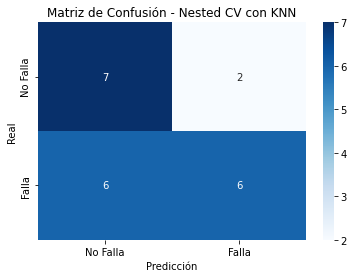

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.54      0.78      0.64         9
           1       0.75      0.50      0.60        12

    accuracy                           0.62        21
   macro avg       0.64      0.64      0.62        21
weighted avg       0.66      0.62      0.62        21



In [72]:
# Evaluación final
print("Nested CV Scores: ", nested_scores)
print("Mean Accuracy: {:.4f} ± {:.4f}".format(np.mean(nested_scores), np.std(nested_scores)))

# Matriz de Confusión
conf_matrix = confusion_matrix(all_y_true, all_y_pred)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Falla", "Falla"], yticklabels=["No Falla", "Falla"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Nested CV con KNN")
plt.show()

# Reporte de clasificación
print("Reporte de clasificación:\n", classification_report(all_y_true, all_y_pred))

### Modelo  L1/L2 Penalty Logistic Regression

In [73]:
from sklearn.linear_model import LogisticRegression

# Definir variables predictoras y objetivo
X = df.drop(columns=["Equipo", "Suspension", "Falla"])  # Ajusta según tus datos
y = df["Falla"]

# Crear pipeline con escalado y L1/L2 Penalty Logistic Regression
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))

# Definir hiperparámetros para GridSearch
param_grid = {
    "logisticregression__penalty": ["l1", "l2"],
    "logisticregression__C": [0.01, 0.1, 1, 10],
    "logisticregression__solver": ["liblinear", "saga"]
}

# Definir Nested Cross-Validation
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Variables para guardar resultados
all_y_true = []
all_y_pred = []
nested_scores = []
best_params_list = []  # Guardamos los mejores hiperparámetros en cada iteración

# Iterar sobre los folds de la validación externa
for train_idx, test_idx in cv_outer.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Aplicar SMOTE a los datos de entrenamiento
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Aplicar GridSearchCV dentro de cada fold
    grid_search = GridSearchCV(pipe, param_grid, cv=cv_inner, scoring="accuracy", n_jobs=-1)
    grid_search.fit(X_train_res, y_train_res)  

    # Guardar los mejores hiperparámetros de esta iteración
    best_params_list.append(frozenset(grid_search.best_params_.items()))

    # Obtener el mejor modelo y hacer predicciones en el conjunto de prueba
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # Guardar resultados
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    nested_scores.append(grid_search.best_score_)

# Encontrar los hiperparámetros más frecuentes
best_overall_params = Counter(best_params_list).most_common(1)[0][0]
best_overall_params = dict(best_overall_params)  # Convertimos de nuevo a diccionario

# Eliminamos los prefijos
best_params = {k.replace("logisticregression__", ""): v for k, v in best_overall_params.items()}

print("Mejores hiperparámetros globales:", best_params)

Mejores hiperparámetros globales: {'solver': 'liblinear', 'penalty': 'l2', 'C': 10}


Nested CV Scores:  [0.9444444444444445, 0.6666666666666666, 0.6507936507936507, 0.746031746031746, 0.7936507936507936]
Mean Accuracy: 0.7603 ± 0.1058


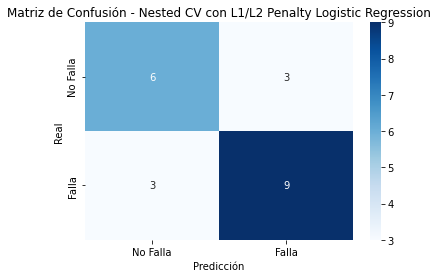

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.67      0.67      0.67         9
           1       0.75      0.75      0.75        12

    accuracy                           0.71        21
   macro avg       0.71      0.71      0.71        21
weighted avg       0.71      0.71      0.71        21



In [74]:
# Mostrar resultados de Nested Cross-Validation
print("Nested CV Scores: ", nested_scores)
print("Mean Accuracy: {:.4f} ± {:.4f}".format(np.mean(nested_scores), np.std(nested_scores)))

# Matriz de Confusión
conf_matrix = confusion_matrix(all_y_true, all_y_pred)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Falla", "Falla"], yticklabels=["No Falla", "Falla"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Nested CV con L1/L2 Penalty Logistic Regression")
plt.show()

# Métricas adicionales
print("Reporte de clasificación:\n", classification_report(all_y_true, all_y_pred))

### Modelo Random Forest 

In [75]:
from sklearn.ensemble import RandomForestClassifier

# Definir variables predictoras y objetivo
X = df.drop(columns=["Equipo", "Suspension", "Falla"])  # Ajusta según tus datos
y = df["Falla"]

# Crear pipeline con escalado y Random Forest
pipe = make_pipeline(StandardScaler(), RandomForestClassifier())

# Definir hiperparámetros para GridSearch
param_grid = {
    "randomforestclassifier__n_estimators": [100, 200, 300],  # Número de árboles
    "randomforestclassifier__max_depth": [10, 20, None],  # Profundidad del árbol
    "randomforestclassifier__min_samples_split": [2, 5],  # Mínimos datos para dividir un nodo
    "randomforestclassifier__min_samples_leaf": [1, 2]  # Mínimos datos en una hoja
}

# Definir Nested Cross-Validation
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Variables para guardar resultados
all_y_true = []
all_y_pred = []
nested_scores = []
best_params_list = []  # Guardamos los mejores hiperparámetros en cada iteración

# Iterar sobre los folds de la validación externa
for train_idx, test_idx in cv_outer.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Aplicar SMOTE a los datos de entrenamiento
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Aplicar GridSearchCV dentro de cada fold
    grid_search = GridSearchCV(pipe, param_grid, cv=cv_inner, scoring="accuracy", n_jobs=-1)
    grid_search.fit(X_train_res, y_train_res)  

    # Guardar los mejores hiperparámetros de esta iteración
    best_params_list.append(frozenset(grid_search.best_params_.items()))

    # Obtener el mejor modelo y hacer predicciones en el conjunto de prueba
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # Guardar resultados
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    nested_scores.append(grid_search.best_score_)

# Encontrar los hiperparámetros más frecuentes
best_overall_params = Counter(best_params_list).most_common(1)[0][0]
best_overall_params = dict(best_overall_params)  # Convertimos de nuevo a diccionario

# Eliminamos los prefijos
best_params = {k.replace("randomforestclassifier__", ""): v for k, v in best_overall_params.items()}

print("Mejores hiperparámetros globales:", best_params)

Mejores hiperparámetros globales: {'min_samples_leaf': 1, 'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 5}


Nested CV Scores:  [0.7777777777777778, 0.5555555555555555, 0.5396825396825397, 0.746031746031746, 0.8412698412698413]
Mean Accuracy: 0.6921 ± 0.1220


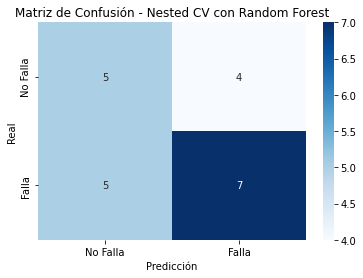

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.50      0.56      0.53         9
           1       0.64      0.58      0.61        12

    accuracy                           0.57        21
   macro avg       0.57      0.57      0.57        21
weighted avg       0.58      0.57      0.57        21



In [76]:
# Mostrar resultados de Nested Cross-Validation
print("Nested CV Scores: ", nested_scores)
print("Mean Accuracy: {:.4f} ± {:.4f}".format(np.mean(nested_scores), np.std(nested_scores)))

# Matriz de Confusión
conf_matrix = confusion_matrix(all_y_true, all_y_pred)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Falla", "Falla"], yticklabels=["No Falla", "Falla"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Nested CV con Random Forest")
plt.show()

# Métricas adicionales
print("Reporte de clasificación:\n", classification_report(all_y_true, all_y_pred))

### Modelo XGBoost

In [77]:
from xgboost import XGBClassifier  # Para clasificación

# Definir variables predictoras y objetivo
X = df.drop(columns=["Equipo", "Suspension", "Falla"])  # Ajusta según tus datos
y = df["Falla"]

# Crear pipeline con escalado y XGBoost
pipe = make_pipeline(StandardScaler(), XGBClassifier(tree_method='hist'))

# Definir hiperparámetros para GridSearch
param_grid = {
    'xgbclassifier__n_estimators': [100, 200],  
    'xgbclassifier__max_depth': [3, 6, 9],  
    'xgbclassifier__learning_rate': [0.01, 0.1, 0.2],  
    'xgbclassifier__colsample_bytree': [0.5, 0.8, 1.0]  
}

# Definir Nested Cross-Validation
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Variables para guardar resultados
all_y_true = []
all_y_pred = []
nested_scores = []
best_params_list = []  # Guardamos los mejores hiperparámetros en cada iteración

# Iterar sobre los folds de la validación externa
for train_idx, test_idx in cv_outer.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Aplicar SMOTE a los datos de entrenamiento
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Aplicar GridSearchCV dentro de cada fold
    grid_search = GridSearchCV(pipe, param_grid, cv=cv_inner, scoring="accuracy", n_jobs=-1)
    grid_search.fit(X_train_res, y_train_res)  

    # Guardar los mejores hiperparámetros de esta iteración
    best_params_list.append(frozenset(grid_search.best_params_.items()))

    # Obtener el mejor modelo y hacer predicciones en el conjunto de prueba
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # Guardar resultados
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    nested_scores.append(grid_search.best_score_)

# Encontrar los hiperparámetros más frecuentes
best_overall_params = Counter(best_params_list).most_common(1)[0][0]
best_overall_params = dict(best_overall_params)  # Convertimos de nuevo a diccionario

# Eliminamos los prefijos
best_params = {k.replace("xgbclassifier__", ""): v for k, v in best_overall_params.items()}

print("Mejores hiperparámetros globales:", best_params)

Mejores hiperparámetros globales: {'max_depth': 3, 'n_estimators': 100, 'learning_rate': 0.1, 'colsample_bytree': 0.5}


Nested CV Scores:  [0.7777777777777778, 0.6666666666666666, 0.6587301587301587, 0.8015873015873015, 0.746031746031746]
Mean Accuracy: 0.7302 ± 0.0579


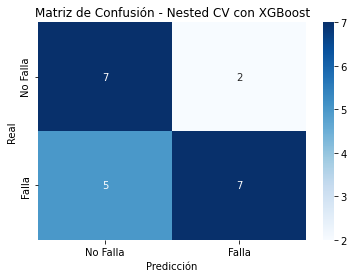

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.58      0.78      0.67         9
           1       0.78      0.58      0.67        12

    accuracy                           0.67        21
   macro avg       0.68      0.68      0.67        21
weighted avg       0.69      0.67      0.67        21



In [78]:
# Mostrar resultados de Nested Cross-Validation
print("Nested CV Scores: ", nested_scores)
print("Mean Accuracy: {:.4f} ± {:.4f}".format(np.mean(nested_scores), np.std(nested_scores)))

# Matriz de Confusión
conf_matrix = confusion_matrix(all_y_true, all_y_pred)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Falla", "Falla"], yticklabels=["No Falla", "Falla"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Nested CV con XGBoost")
plt.show()

# Métricas adicionales
print("Reporte de clasificación:\n", classification_report(all_y_true, all_y_pred))

### Modelo SVM (Support Vector Machines)

In [80]:
from sklearn.svm import SVC

# Definir variables predictoras y objetivo
X = df.drop(columns=["Equipo", "Suspension", "Falla"])  # Ajusta según tus datos
y = df["Falla"]

# Crear pipeline con escalado y SVM
pipeline = Pipeline([
    ('standardscaler', StandardScaler()),
    ('svc', SVC())  
])

# Definir hiperparámetros para GridSearch
param_grid = {'svc__C': [0.001, 0.01, 0.1, 1, 10, 100], 
              'svc__gamma': [0.001, 0.01, 0.1, 1, 10, 100],
              'svc__kernel': ['linear', 'rbf', 'poly', 'sigmoid']
              }

# Definir Nested Cross-Validation
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Variables para guardar resultados
all_y_true = []
all_y_pred = []
nested_scores = []
best_params_list = []  # Guardamos los mejores hiperparámetros en cada iteración

# Iterar sobre los folds de la validación externa
for train_idx, test_idx in cv_outer.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Aplicar SMOTE a los datos de entrenamiento
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Aplicar GridSearchCV dentro de cada fold
    grid_search = GridSearchCV(pipeline, param_grid, cv=cv_inner, scoring="accuracy", n_jobs=-1)
    grid_search.fit(X_train_res, y_train_res)  

    # Guardar los mejores hiperparámetros de esta iteración
    best_params_list.append(frozenset(grid_search.best_params_.items()))

    # Obtener el mejor modelo y hacer predicciones en el conjunto de prueba
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # Guardar resultados
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    nested_scores.append(grid_search.best_score_)

# Encontrar los hiperparámetros más frecuentes
best_overall_params = Counter(best_params_list).most_common(1)[0][0]
best_overall_params = dict(best_overall_params)  # Convertimos de nuevo a diccionario

# Eliminamos los prefijos 'svc__' para pasarlos correctamente a SVC()
best_svc_params = {k.replace("svc__", ""): v for k, v in best_overall_params.items()}

print("Mejores hiperparámetros globales:", best_svc_params)


Mejores hiperparámetros globales: {'gamma': 0.1, 'C': 1, 'kernel': 'rbf'}


Nested CV Scores:  [0.888888888888889, 0.7222222222222223, 0.753968253968254, 0.8492063492063492, 0.8968253968253969]
Mean Accuracy: 0.8222 ± 0.0713


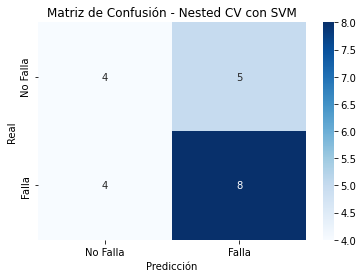

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.50      0.44      0.47         9
           1       0.62      0.67      0.64        12

    accuracy                           0.57        21
   macro avg       0.56      0.56      0.56        21
weighted avg       0.57      0.57      0.57        21



In [82]:
# Evaluación final
print("Nested CV Scores: ", nested_scores)
print("Mean Accuracy: {:.4f} ± {:.4f}".format(np.mean(nested_scores), np.std(nested_scores)))

# Matriz de Confusión
conf_matrix = confusion_matrix(all_y_true, all_y_pred)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Falla", "Falla"], yticklabels=["No Falla", "Falla"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Nested CV con SVM")
plt.show()

# Reporte de clasificación
print("Reporte de clasificación:\n", classification_report(all_y_true, all_y_pred))

### Modelo ANN (Redes Neuronales Artificiales)



In [91]:
from sklearn.neural_network import MLPClassifier

# Definir variables predictoras y objetivo
X = df.drop(columns=["Equipo", "Suspension", "Falla"])  # Ajusta según tus datos
y = df["Falla"]

# Crear pipeline con escalado y MLP
pipe = make_pipeline(StandardScaler(),  MLPClassifier(max_iter=1000000, random_state=42))

# Definir hiperparámetros para GridSearch
param_grid = {
    'mlpclassifier__hidden_layer_sizes': [(5,), (10,), (15,), (20,)],  # Número de neuronas en las capas ocultas
    'mlpclassifier__activation': ['relu', 'tanh', 'logistic'],  # Función de activación
    'mlpclassifier__solver': ['adam', 'sgd'],  # Algoritmo de optimización
    'mlpclassifier__alpha': [0.0001, 0.001, 0.01],  # Parámetro de regularización L2
    'mlpclassifier__learning_rate': ['constant', 'adaptive'],  # Estrategia de tasa de aprendizaje
}

# Definir Nested Cross-Validation
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Variables para guardar resultados
all_y_true = []
all_y_pred = []
nested_scores = []
best_params_list = []  # Guardamos los mejores hiperparámetros en cada iteración

# Iterar sobre los folds de la validación externa
for train_idx, test_idx in cv_outer.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Aplicar SMOTE a los datos de entrenamiento
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Aplicar GridSearchCV dentro de cada fold
    grid_search = GridSearchCV(pipe, param_grid, cv=cv_inner, scoring="accuracy", n_jobs=-1)
    grid_search.fit(X_train_res, y_train_res)  

    # Guardar los mejores hiperparámetros de esta iteración
    best_params_list.append(frozenset(grid_search.best_params_.items()))

    # Obtener el mejor modelo y hacer predicciones en el conjunto de prueba
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # Guardar resultados
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    nested_scores.append(grid_search.best_score_)

# Encontrar los hiperparámetros más frecuentes
best_overall_params = Counter(best_params_list).most_common(1)[0][0]
best_overall_params = dict(best_overall_params)  # Convertimos de nuevo a diccionario

# Eliminamos los prefijos
best_params = {k.replace("mlpclassifier__", ""): v for k, v in best_overall_params.items()}

print("Mejores hiperparámetros globales:", best_params)

Mejores hiperparámetros globales: {'hidden_layer_sizes': (20,), 'activation': 'relu', 'learning_rate': 'constant', 'solver': 'adam', 'alpha': 0.0001}


Nested CV Scores:  [0.888888888888889, 0.8333333333333334, 0.7936507936507936, 0.7936507936507936, 0.8492063492063492]
Mean Accuracy: 0.8317 ± 0.0360


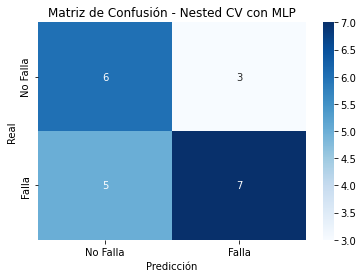

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.55      0.67      0.60         9
           1       0.70      0.58      0.64        12

    accuracy                           0.62        21
   macro avg       0.62      0.62      0.62        21
weighted avg       0.63      0.62      0.62        21



In [92]:
# Evaluación final
print("Nested CV Scores: ", nested_scores)
print("Mean Accuracy: {:.4f} ± {:.4f}".format(np.mean(nested_scores), np.std(nested_scores)))

# Matriz de Confusión
conf_matrix = confusion_matrix(all_y_true, all_y_pred)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Falla", "Falla"], yticklabels=["No Falla", "Falla"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Nested CV con MLP")
plt.show()

# Reporte de clasificación
print("Reporte de clasificación:\n", classification_report(all_y_true, all_y_pred))

### Resultados 